In [ ]:
from apak import * 

# Plot parameters 
plt.rcParams.update({
    "font.family": "serif",
    'text.latex.preamble': r'\\usepackage{amsmath}',
    'mathtext.fontset': 'cm',
})
    
# Functions 
funcs = [
    lambda x: jnp.exp(-5*x)*jnp.sin(10*math.pi*x),
    lambda x: jnp.sin(10*math.pi*x)
]

# creating high and low-fidelity inputs 
n1, n2, n_test = 10, 100, 1000
rng_key = jrand.PRNGKey(seed = 42)
hi_key, lo_key, test_key = random.split(rng_key, 3)
X1 = random.uniform(hi_key, shape = (n1, 1))
X2 = random.uniform(lo_key, shape = (n2, 1))
Xtest = random.uniform(test_key, shape = (n_test, 1))

# Creating high and low-fidelity data 
Y1 = funcs[0](X1).ravel()
Y2 = funcs[1](X2).ravel()
Ytest = funcs[0](Xtest).ravel()

# NN Evaluation function 
def nn_eval(x, p, activation):
    # Store the number of hidden layers 
    n_hidden = len(p['w'])-1
    # Compute initial hidden state 
    h = activation(p['w']['w1'] @ x + p['b']['b1'])
    # Propagating through the additional layers 
    for layer_num in range(2, n_hidden):
        # Computing each hidden layer with activation
        h = activation(p['w']['w%d'%layer_num]@h + p['b']['b%d' % layer_num])
    # Compute the last layer (without activation)
    return (p['w']['w%d' % (n_hidden+1)] @ h + p['b']['b%d' % (n_hidden+1)]).T

# KL-Divergence function for z = N(0,I)
# sigma should be a 1D diagonal vector
def KL_z(mu, sigma):
    return 0.5 * (-jnp.sum(jnp.log(sigma)) - mu.shape[0] + jnp.sum(sigma) + jnp.inner(mu, mu))

def single_likelihood(key, y_i, encoder_mean, encoder_var, p_d, noise_var, activation):
    # Drawing a random z 
    z_i = encoder_mean + jnp.sqrt(encoder_var) * random.uniform(key, shape = (encoder_mean.shape[0]))
    # Evaluating the neural net 
    decoder_pred = nn_eval(z_i.reshape(-1,1), p_d, activation)
    # Evaluating the terms 
    return -0.5*((y_i - decoder_pred)**2 / noise_var + jnp.log(2*math.pi*noise_var)) 

# Softplus function for positivity-enforcement
def softplus(x):
    """Softplus activation: log(1 + exp(x))."""
    return jnp.log(1.0 + jnp.exp(x))
def inv_softplus(y):
    """Inverse softplus: maps positive values back to unconstrained space."""
    return jnp.log(jnp.exp(y) - 1.0)

def single_elbo(key, y_i, x_i, p_e, p_d, noise_var, N_mc, activation):
    # Splitting RNG keys 
    keys = random.split(key, num=N_mc)
    # Obtaining encoder mean and variance at input x_i 
    encoder_mean = nn_eval(x_i.reshape(1,-1), p_e['mean'], activation) 
    encoder_var = softplus(nn_eval(x_i.reshape(1,-1), p_e['var'], activation))
    # Vmapping over RNG keys 
    exp_likelihood = jnp.mean(
        jax.vmap(lambda key: single_likelihood(
            key, y_i, encoder_mean, 
            encoder_var, 
            p_d, 
            noise_var,
            activation
    ))(keys))
    # KL-Divergence term 
    kl_term = KL_z(encoder_mean, encoder_var)
    return exp_likelihood - kl_term

def elbo(key, p_e, p_d, X, Y, noise_var, N_mc, activation):
    # splitting rng keys 
    keys = random.split(key, num=X.shape[0])
    # Evaluating the elbo over all the data 
    return jnp.sum(jax.vmap(
        lambda key,x,y: single_elbo(
            key, y, x, p_e, p_d, noise_var, N_mc, activation
        ), in_axes = (0, 0, 0)
    ) (keys, X, Y))

# Defining loss function
def loss(p, key, X1, Y1, X2, Y2, N_mc, activation):
    # Getting the parameters for the encoder and decoders 
    p_e, p_d1, p_d2 = p['e'], p['d1'], p['d2']
    # Getting the noise variances 
    noise_var1, noise_var2 = softplus(p['noise_var1']), softplus(p['noise_var2'])
    # Evaluating the ELBO at the high-fidelity data 
    hf_key, lf_key = random.split(key, num = 2)
    elbo_1 = elbo(
        hf_key, 
        p_e, 
        p_d1, 
        X1, Y1, noise_var1, 
        N_mc, activation
    )
    # Evaluating the ELBO at the low-fidelity data 
    elbo_2 = elbo(
        lf_key, 
        p_e, 
        p_d2, 
        X2, Y2, noise_var2,
        N_mc, activation
    )
    return (elbo_1 + elbo_2) / (X1.shape[0] + X2.shape[0])

# Making online predictions 
def predict(Xtest, p, N_mc, activation, seed=42):
    # A single monte-carlo prediction for a given input 
    def single_prediction(key, p_d, encoder_mean, encoder_var, activation):
        # Sampling a single z 
        z_i = encoder_mean + jnp.sqrt(encoder_var)*random.uniform(key, shape = (encoder_mean.shape[0]))
        # Sampling a single prediction from the latent space
        return nn_eval(z_i.reshape(-1,1), p_d, activation).ravel()
    
    # A single pass through all the inputs 
    def single_pass(key, p_d, encoder_means, encoder_vars):
        # Splitting the RNG keys into the number of data points
        keys = random.split(key, num=encoder_means.shape[0])
        # Vmapping for each input 
        return jax.vmap(
            lambda key, mean, var:single_prediction(
                key, p_d, mean, var, activation
            ), in_axes = (0, 0, 0)
        )(keys, encoder_means, encoder_vars).ravel()

    # Getting the parameters for the encoder and decoders 
    p_e, p_d = p['e'], p['d1']
    
    # Encoder mean and variances 
    encoder_means = nn_eval(Xtest.T, p_e['mean'], activation)
    encoder_vars = softplus(nn_eval(Xtest.T, p_e['var'], activation))

    # Mapping over the number of monte-carlo samples 
    key = random.PRNGKey(seed)
    keys = random.split(key, num=N_mc)

    # Making predictions using jax.vmap
    preds = jax.vmap(
        lambda key: single_pass(
            key, 
            p_d, 
            encoder_means, 
            encoder_vars
        )
    )(keys)
    return preds



# Obtaining input and hidden dimensions
d, h_dim, z_dim = X1.shape[1], 50, 25
np.random.seed(42)
scalar = 1e-2
p = {
    'e':{
        'mean':{
            'w':{
                'w1':scalar*randn(h_dim, d),
                'w2':scalar*randn(h_dim, h_dim),
                'w3':scalar*randn(h_dim, h_dim),
                'w4':scalar*randn(z_dim, h_dim)
            },
            'b':{
                'b1':zeros((h_dim,1)),
                'b2':zeros((h_dim,1)),
                'b3':zeros((h_dim,1)),
                'b4':zeros((z_dim,1))
            }
        }, 
        'var':{
            'w':{
                'w1':scalar*randn(h_dim, d),
                'w2':scalar*randn(h_dim, h_dim),
                'w3':scalar*randn(h_dim, h_dim),
                'w4':scalar*randn(z_dim, h_dim)
            },
            'b':{
                'b1':zeros((h_dim,1)),
                'b2':zeros((h_dim,1)),
                'b3':zeros((h_dim,1)),
                'b4':zeros((z_dim,1))
            }
        }
    }, 
    'd1':{
        'w':{
                'w1':scalar*randn(h_dim, z_dim),
                'w2':scalar*randn(h_dim, h_dim),
                'w3':scalar*randn(h_dim, h_dim),
                'w4':scalar*randn(1, h_dim)
            },
            'b':{
                'b1':zeros((h_dim,1)),
                'b2':zeros((h_dim,1)),
                'b3':zeros((h_dim,1)),
                'b4':zeros(1)
            }
    },
    'd2':{
        'w':{
                'w1':scalar*randn(h_dim, z_dim),
                'w2':scalar*randn(h_dim, h_dim),
                'w3':scalar*randn(h_dim, h_dim),
                'w4':scalar*randn(1, h_dim)
            },
            'b':{
                'b1':zeros((h_dim,1)),
                'b2':zeros((h_dim,1)),
                'b3':zeros((h_dim,1)),
                'b4':zeros(1)
            }
    }, 
    'noise_var1':inv_softplus(1e-8), 
    'noise_var2':inv_softplus(1e-8)
}

v = jax.tree.map(jnp.zeros_like, p)

loss_key = random.PRNGKey(seed=42)

grad_func = value_and_grad(
    jax.jit(lambda p: -loss(
        p, loss_key, 
        X1, Y1, X2, Y2, 25, jnp.tanh
    ))
)
loss, grad = grad_func(p)
print("Initial Loss: %3e" % loss)

AttributeError: '_cython_3_1_4.cython_function_or_method' object has no attribute 'split'

In [14]:
epochs, lr, beta = 10000, 2e0, 0.9
iterator = tqdm(range(epochs))

for iter in iterator:
    loss, grad = grad_func(p)
    iterator.set_postfix_str("Loss: %.4e" % (loss))
    # Updating the parameters
    v = jax.tree.map(lambda v, g: beta * v - lr * g, v,grad)
    p = jax.tree.map(lambda p, v: p + v, p, v)

 49%|████▉     | 4914/10000 [00:36<00:37, 134.74it/s, Loss: nan]       


KeyboardInterrupt: 

In [ ]:
yhat = predict(
    Xtest, p, 25, jnp.tanh, seed=42
)

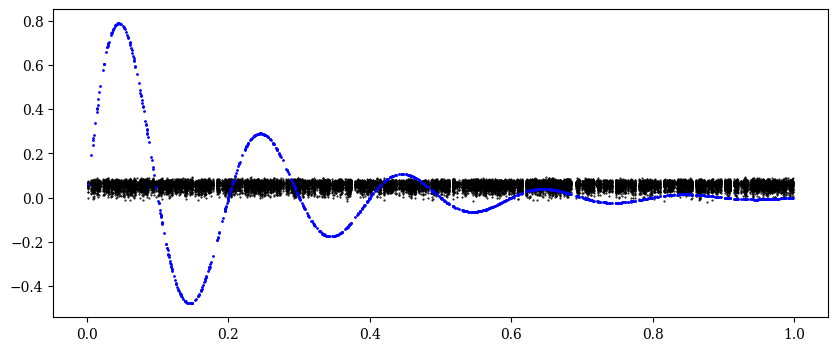

In [ ]:
plt.figure(figsize=(10,4))
for i in range(yhat.shape[0]):
    plt.scatter(Xtest.ravel(), yhat[i,:], s = 1.0, color = 'black', marker = '.')

plt.scatter(Xtest.ravel(), Ytest.ravel(), s = 1.0, color = 'blue')